# Proyecto final

## 1. Carga y análisis exploratorio de datos

In [1]:
from scipy import stats
import datetime as dt
import pandas as pd
import numpy as np
import math as mt
import seaborn as sns
import matplotlib.pyplot as plt

### 1.1 Revisión de bases de datos

In [2]:
telecom = pd.read_csv("/datasets/telecom_dataset_us.csv")

In [3]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [4]:
telecom.sample(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
39030,167654,2019-11-27 00:00:00+03:00,out,False,918978.0,True,5,0,108
46583,168105,2019-11-16 00:00:00+03:00,in,False,NaN,True,2,0,18
35063,167521,2019-11-12 00:00:00+03:00,in,False,944210.0,False,7,404,479
16362,166916,2019-10-10 00:00:00+03:00,out,False,906404.0,True,4,0,130
8272,166658,2019-09-05 00:00:00+03:00,out,False,891152.0,False,3,512,547
45794,168064,2019-11-12 00:00:00+03:00,in,False,939762.0,False,29,2194,2710
28026,167176,2019-11-08 00:00:00+03:00,out,True,907964.0,False,1,23,28
52874,168361,2019-11-21 00:00:00+03:00,out,False,945278.0,False,152,8932,12195
23229,167078,2019-11-19 00:00:00+03:00,out,False,900592.0,True,1,0,5
42325,167949,2019-10-31 00:00:00+03:00,out,False,941384.0,True,6,0,259


Aquí hay varias cosas a tomar en cuenta:
* Primero que nada hay que estandarízar las fechas, por lo qué es necesario el trbajo
* El identificador de operado cuenta con valores flotantes y no enteros como debería de ser.
* El operador internal tiene alrededor de 200 valores vacios, por lo que considerando el tamaño de la muestra, mejor purgar.
* Hacer una prueba y explorar los datos que hay en operator_id, faltan muchos datos y si son omisiones habrá que hacer una purga pues no sabemos con certeza como llenar esos datos.

In [5]:
telecom['date'] = pd.to_datetime(telecom['date'])

In [6]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  int64                                
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  object                               
 3   internal             53785 non-null  object                               
 4   operator_id          45730 non-null  float64                              
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
dtypes: bool

In [7]:
telecom.sample(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
22532,167060,2019-11-20 00:00:00+03:00,out,False,930914.0,False,2,82,90
18764,166983,2019-09-13 00:00:00+03:00,in,False,NaN,True,6,0,343
732,166405,2019-08-15 00:00:00+03:00,out,False,882684.0,False,1,151,153
39025,167654,2019-11-27 00:00:00+03:00,in,False,918978.0,False,25,4624,4863
4652,166511,2019-09-30 00:00:00+03:00,out,False,891414.0,False,31,2951,3172
18838,166983,2019-09-20 00:00:00+03:00,out,False,901880.0,True,10,0,371
10889,166680,2019-11-06 00:00:00+03:00,out,False,932500.0,True,9,0,151
49464,168187,2019-11-26 00:00:00+03:00,out,False,937708.0,False,17,881,1191
39277,167716,2019-11-26 00:00:00+03:00,out,False,922142.0,False,17,1001,1325
7164,166582,2019-10-17 00:00:00+03:00,in,False,925922.0,True,2,0,23


In [8]:
print("Elementos NaN en la columna 'internal':",telecom['internal'].isna().sum())

Elementos NaN en la columna 'internal': 117


In [9]:
telecom['internal'] = telecom['internal'].astype('bool')

Ya corregido el elemento temporal, vemos que hay 117 elementos que tienen un NaN, lo cula al hacer la suma con los 53785 nos dan los 53902 que hay en el resto, al ser una muestra pequeña podemos suprimirlos sin problema alguno, pues al ser una caracteristica booleana no hay forma de reemplazarla

In [10]:
print("Elementos NaN en la columna 'operator_id':",telecom['operator_id'].isna().sum())

Elementos NaN en la columna 'operator_id': 8172


In [11]:
print(f"Porcentaje de elementos NaN en la columna 'operator_id', respecto al total de la muestra: {(telecom['operator_id'].isna().sum())/len(telecom['operator_id'])*100:.2f}%")

Porcentaje de elementos NaN en la columna 'operator_id', respecto al total de la muestra: 15.16%


Aquí hay un tema a tratar, hay no pocos elementos NaN en la columna **operator_id**, esto es importante pues representan el 15% de la muestra, esta la opción de borrarolo, lo cual será mi enfoque, pero si fuera otro tipo de prueba parámetrica hay que tener cuidado, pues borrar un 15% de los datos es significativo pues nos da más información que solo el usario, ahora, este analisis es para entender el comportamiento y desempeño de los operadores, por lo que no hay forma de reemplazar esos valores, por lo que se procederá a limpiar la base de datos

In [12]:
telecom = telecom.dropna(subset=['operator_id'], axis=0)

In [13]:
telecom['operator_id'] = telecom['operator_id'].astype('int')

In [14]:
telecom['date'] = telecom['date'].dt.date

In [15]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 45730 entries, 1 to 53900
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              45730 non-null  int64 
 1   date                 45730 non-null  object
 2   direction            45730 non-null  object
 3   internal             45730 non-null  bool  
 4   operator_id          45730 non-null  int64 
 5   is_missed_call       45730 non-null  bool  
 6   calls_count          45730 non-null  int64 
 7   call_duration        45730 non-null  int64 
 8   total_call_duration  45730 non-null  int64 
dtypes: bool(2), int64(5), object(2)
memory usage: 2.9+ MB


In [16]:
clients = pd.read_csv("/datasets/telecom_clients_us.csv")

In [17]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [18]:
clients.sample(10)

,user_id,tariff_plan,date_start
527,168180,B,2019-10-16
173,168381,C,2019-10-23
495,168550,B,2019-10-30
159,166400,C,2019-08-01
330,166833,C,2019-08-21
693,166884,B,2019-08-22
94,166939,C,2019-08-26
496,167419,B,2019-09-16
400,167553,C,2019-09-20
690,167058,B,2019-08-29


In [19]:
clients['date_start'] = pd.to_datetime(clients['date_start'])

In [20]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 17.3+ KB


Con esto, la aprte de corrección está lista, pero debemos hacer un análisis más a profundidad de acuerdo a lo que no interesa y esto es

## 1.2 Analísis exploratorio de datos

Con esta perpectiva debemos ver como se distribuyen diversos elementos, número de llamadas al día, número de llamadas salientes y entrantes por operador, duraciónde llamadas por operador, la distribución de planes por usuarios, y con esto podemos darnos una idea más adecuada de lo que deseamos obtener. 

In [21]:
telecom.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000
mean,167302.220315,916535.993002,16.904417,1009.765121,1322.141789
std,600.731240,21254.123136,59.045234,4014.600085,4732.427880
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000
50%,167175.000000,913938.000000,4.000000,106.000000,290.500000
75%,167827.000000,937708.000000,14.000000,772.000000,1110.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [22]:
External_calls_by_day = telecom[telecom['internal']==False].groupby('date').agg({'user_id':'count'}).reset_index()
External_calls_by_day

,date,user_id
0,2019-08-02,4
1,2019-08-03,5
2,2019-08-04,2
3,2019-08-05,10
4,2019-08-06,13
...,...,...
113,2019-11-24,227
114,2019-11-25,893
115,2019-11-26,844
116,2019-11-27,895


In [23]:
calls_by_day = telecom.groupby('date').agg({'user_id':'count'}).reset_index()
calls_by_day

,date,user_id
0,2019-08-02,6
1,2019-08-03,6
2,2019-08-04,3
3,2019-08-05,14
4,2019-08-06,16
...,...,...
113,2019-11-24,234
114,2019-11-25,1084
115,2019-11-26,1002
116,2019-11-27,1059


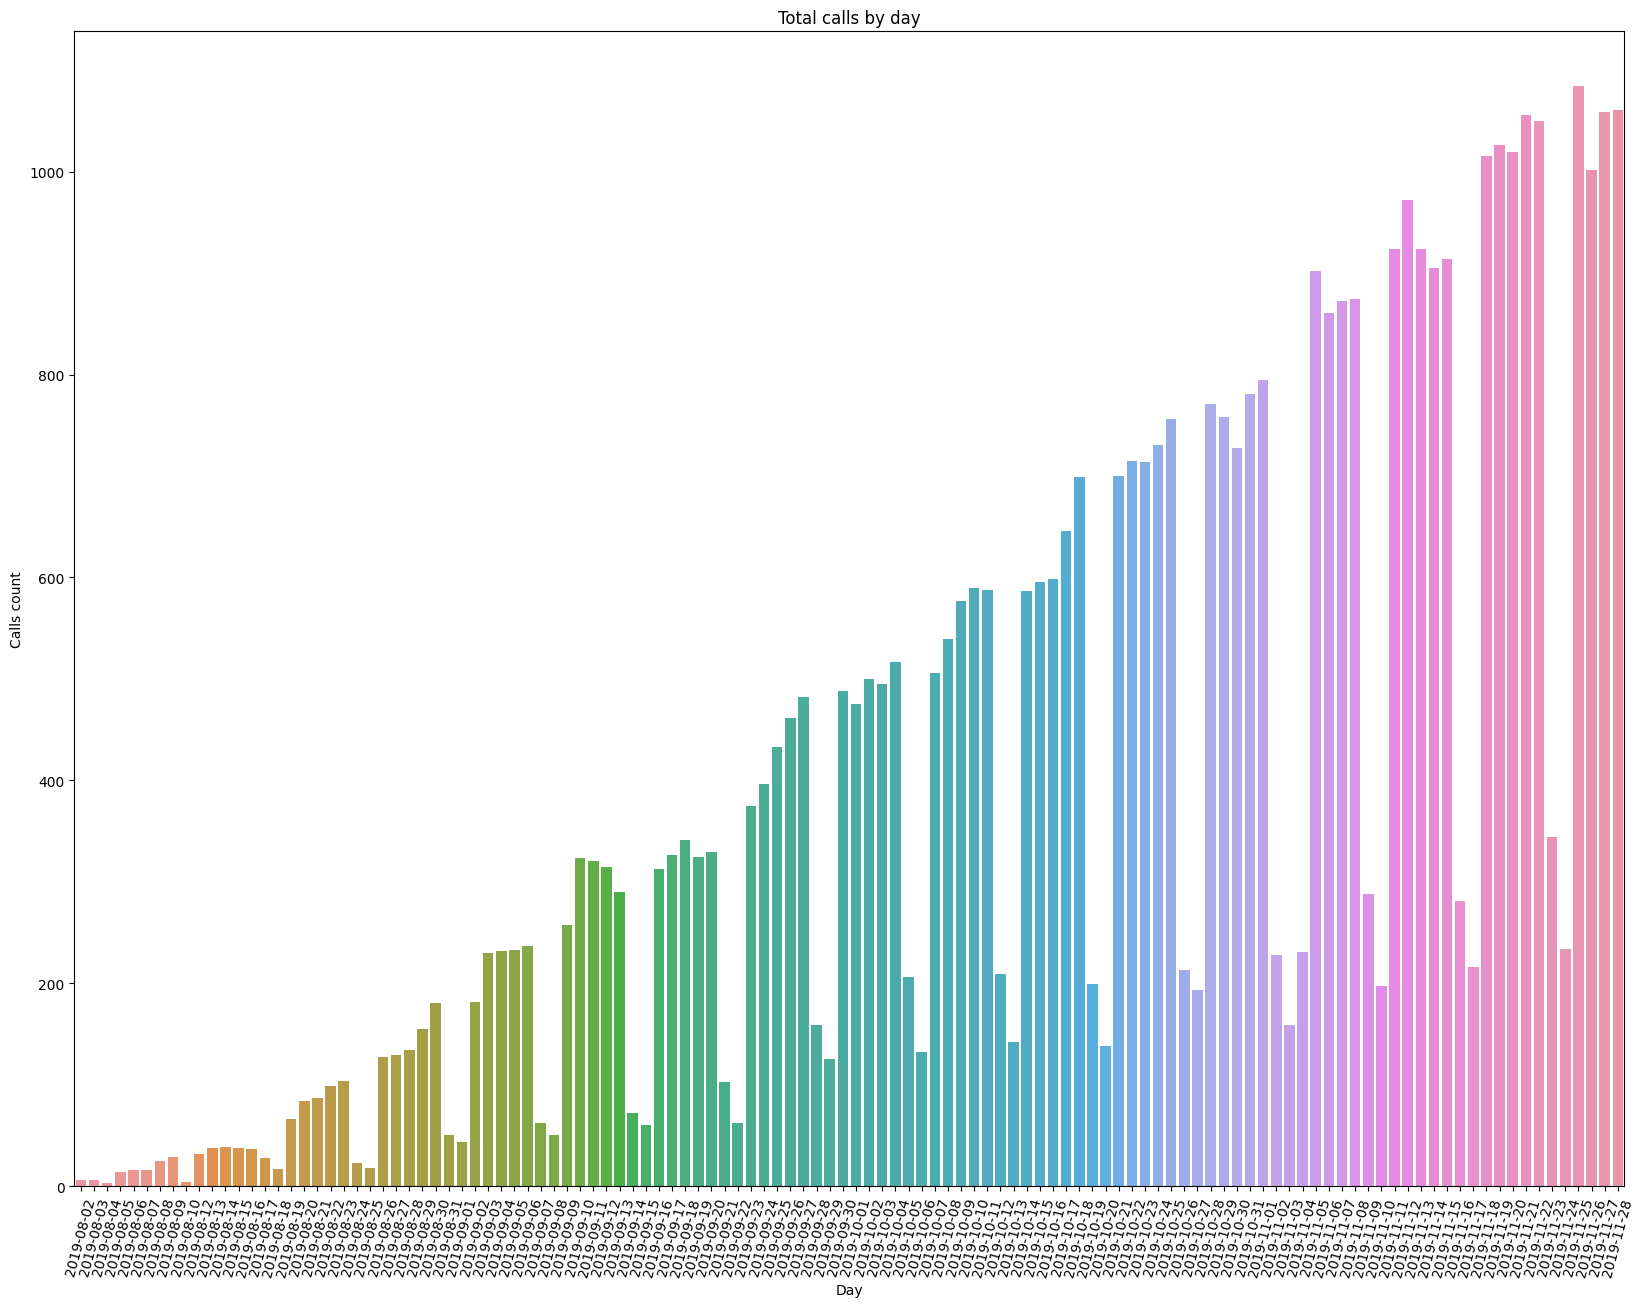

In [24]:
fig, ax = plt.subplots(figsize=(20,15))
sns.barplot(data=calls_by_day, x='date', y='user_id')
plt.title('Total calls by day')
plt.xlabel('Day')
plt.ylabel('Calls count')
plt.xticks(rotation=75)
plt.show()

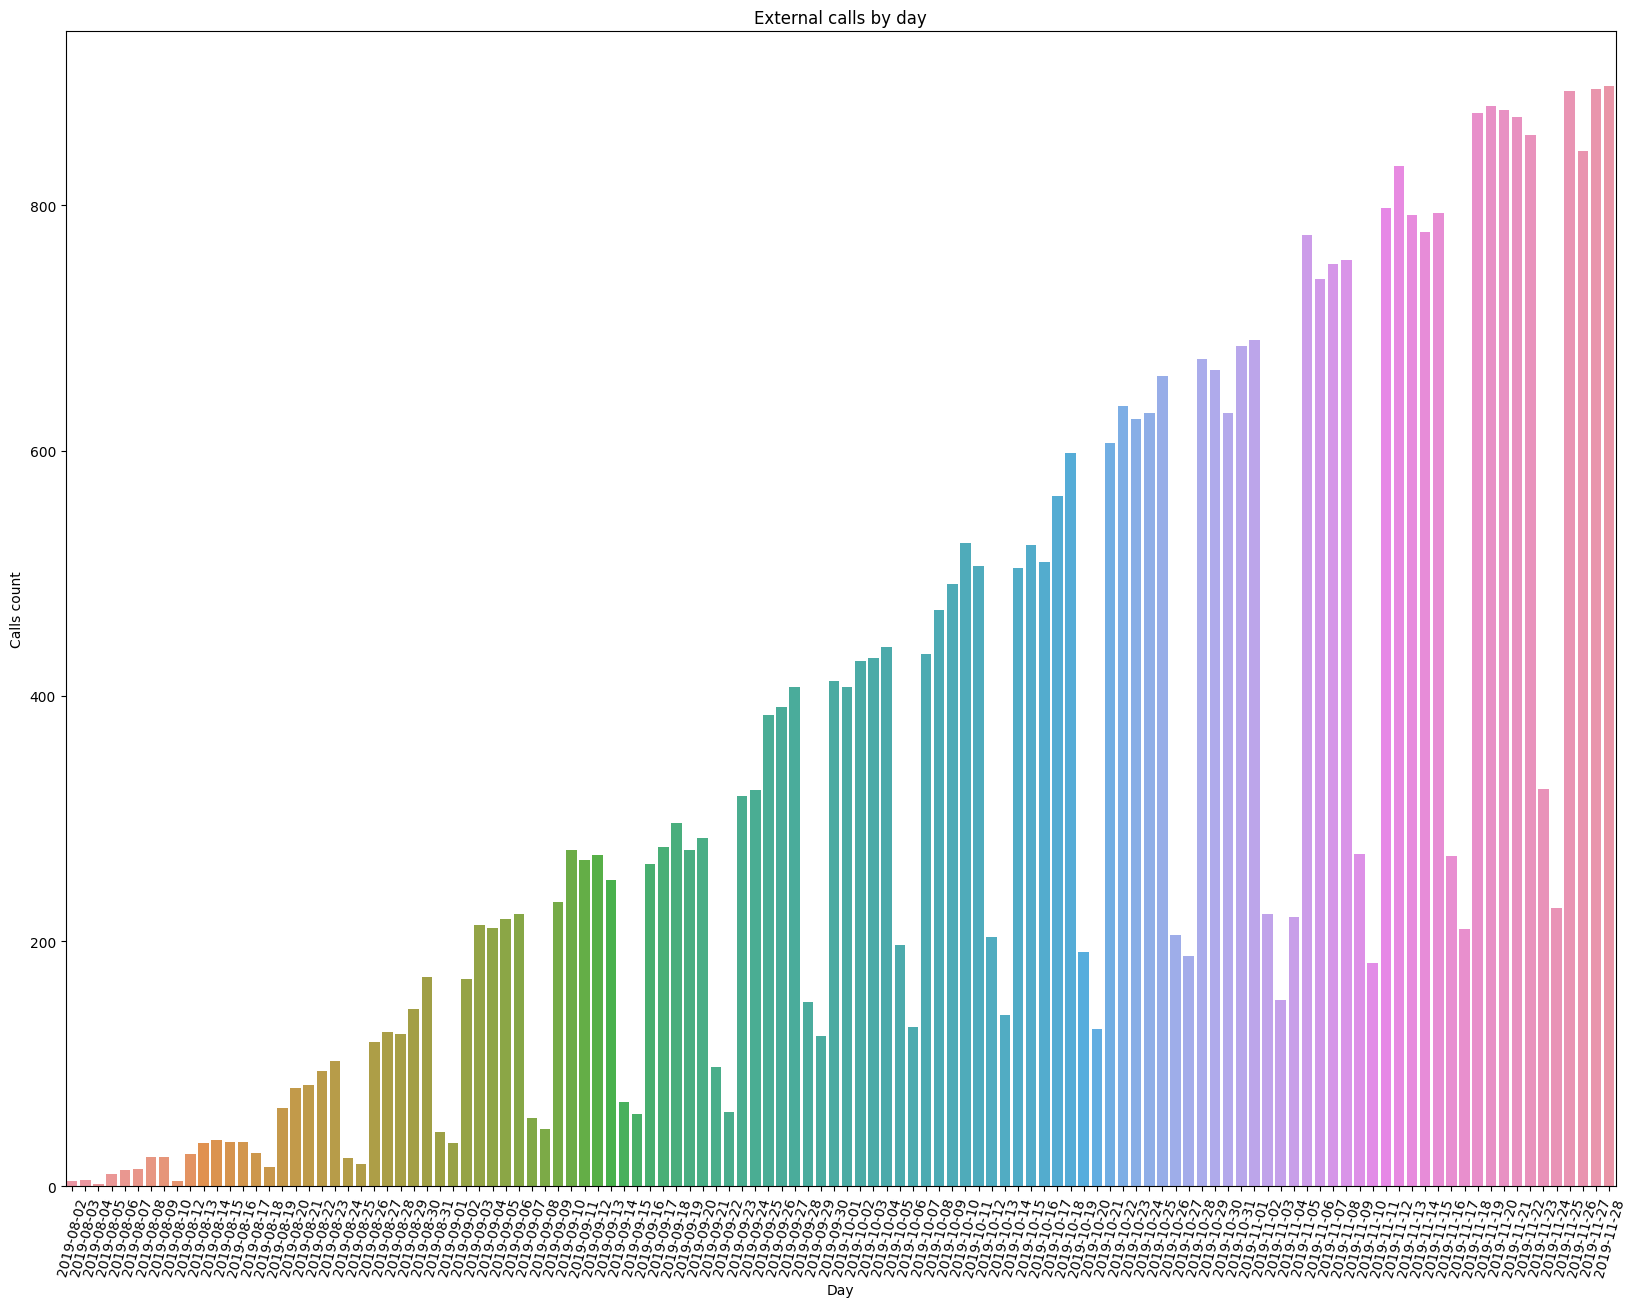

In [25]:
fig, ax = plt.subplots(figsize=(20,15))
sns.barplot(data=External_calls_by_day, x='date', y='user_id')
plt.title('External calls by day')
plt.xlabel('Day')
plt.ylabel('Calls count')
plt.xticks(rotation=75)
plt.show()

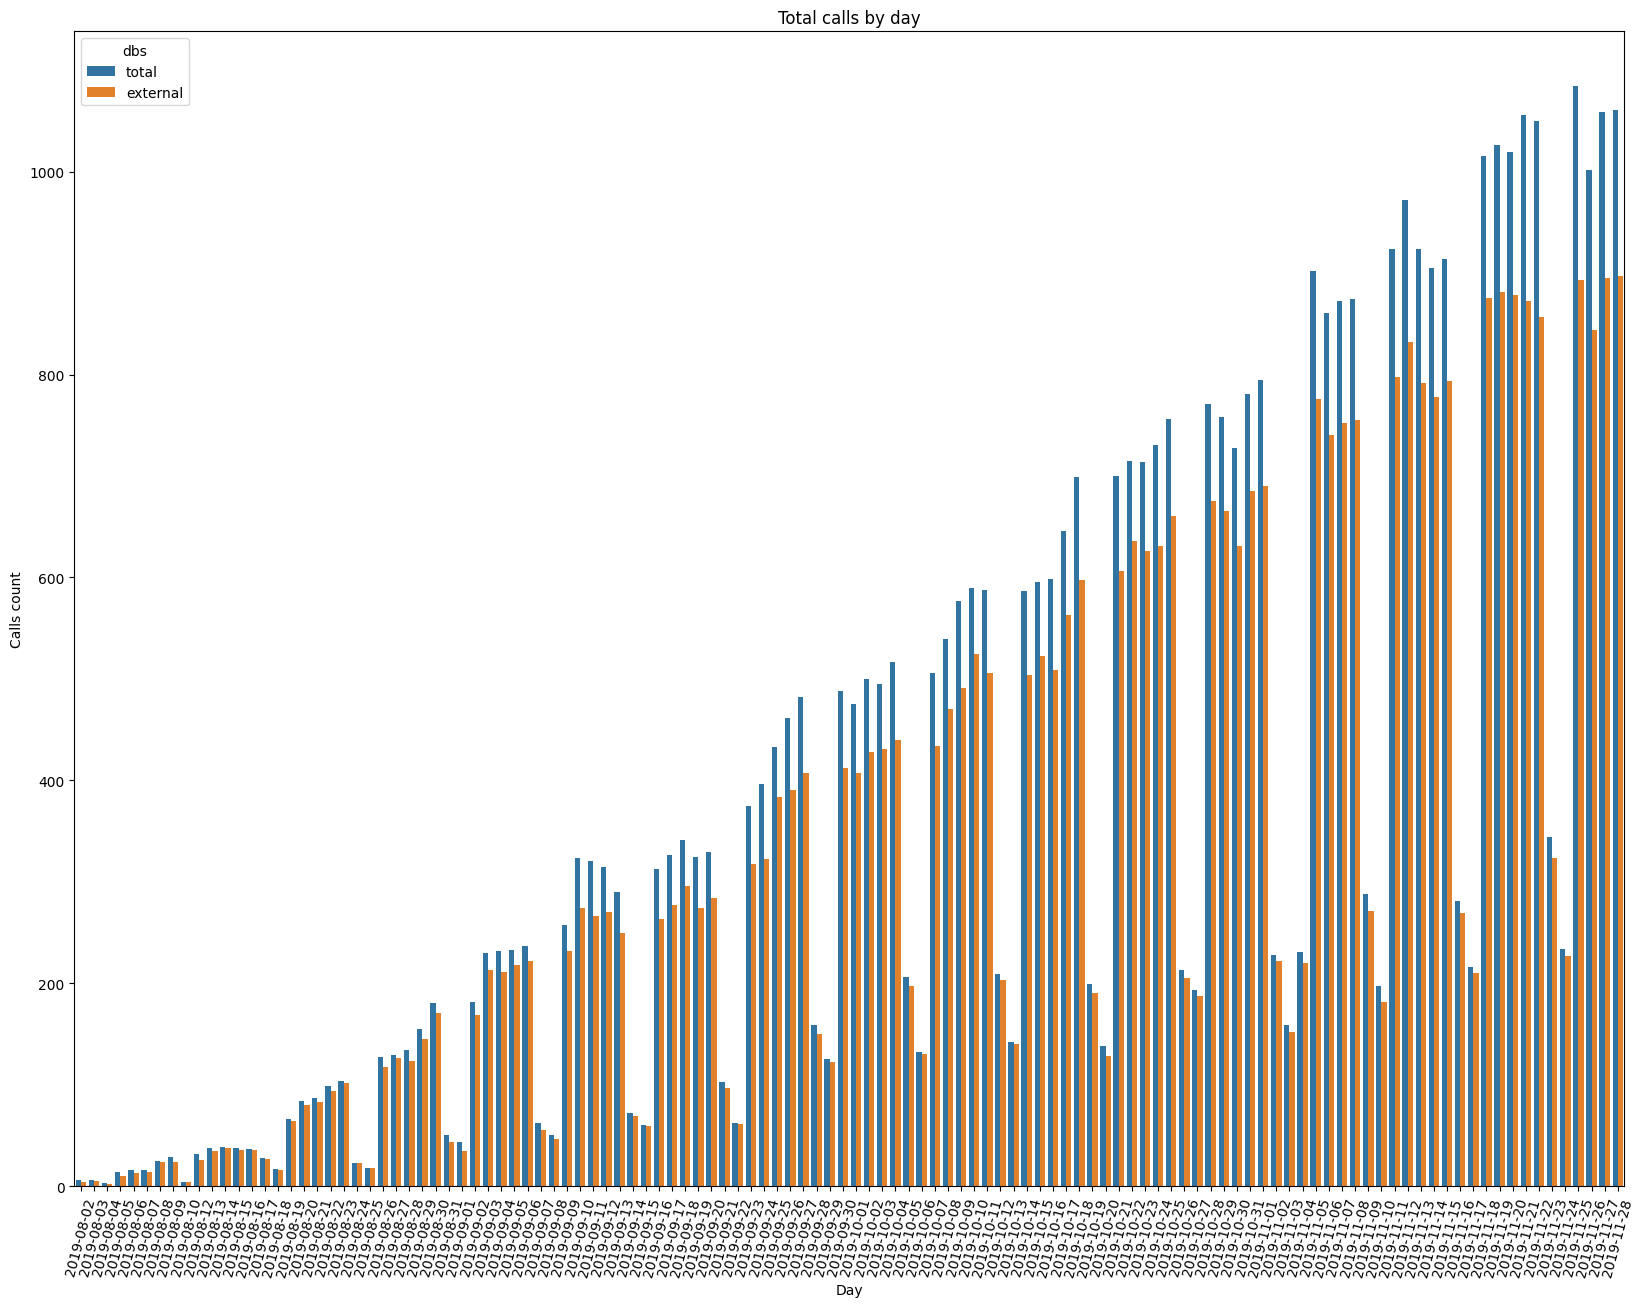

In [26]:
calls_by_day['dbs'] = 'total'
External_calls_by_day['dbs'] = 'external'

comp_data = pd.concat([calls_by_day, External_calls_by_day])

fig, ax = plt.subplots(figsize=(20,15))
sns.barplot(data=comp_data, x='date', y='user_id', hue= 'dbs')
plt.title('Total calls by day')
plt.xlabel('Day')
plt.ylabel('Calls count')
plt.xticks(rotation=75)
plt.show()

Aquí podemos ver cómo la dsitribución de llamadas por día totales y salientes, es decir, que ocurren a elementos ajenos a la oficina en una proporción media, pero para dejar las cuentas claras, hagamos unas operaciones.

In [27]:
calls_by_day['external_calls'] = External_calls_by_day['user_id']
calls_by_day['percent'] = calls_by_day['external_calls']/calls_by_day['user_id']*100
calls_by_day

,date,user_id,dbs,external_calls,percent
0,2019-08-02,6,total,4,66.666667
1,2019-08-03,6,total,5,83.333333
2,2019-08-04,3,total,2,66.666667
3,2019-08-05,14,total,10,71.428571
4,2019-08-06,16,total,13,81.250000
...,...,...,...,...,...
113,2019-11-24,234,total,227,97.008547
114,2019-11-25,1084,total,893,82.380074
115,2019-11-26,1002,total,844,84.231537
116,2019-11-27,1059,total,895,84.513692


In [28]:
print(f"Promedio porcentual de llamadas externas respecto a las totales del dia: {np.mean(calls_by_day['percent']):.2f}%")

Promedio porcentual de llamadas externas respecto a las totales del dia: 89.34%


Por lo cual podemos decir que el promedio de llamadas del día es cerca del 90%, lo cual es una buena estadística para el equipo en general, sin embargo estamos midiendo el desempeño de operadores individuales, los cuales podemos obtener de la siguiente manera.

In [29]:
Calls_by_op = telecom.groupby('operator_id').agg({'user_id':'count', 'call_duration':'sum', 'total_call_duration':'sum'}).reset_index()
Calls_by_op.rename(columns={'user_id':'total_calls', 'call_duration':'total_call_time', 'total_call_duration':'total_op_time'}, inplace=True)
Calls_by_op['total_dead_time'] = Calls_by_op['total_op_time'] - Calls_by_op['total_call_time']
Calls_by_op

,operator_id,total_calls,total_call_time,total_op_time,total_dead_time
0,879896,128,83261,97427,14166
1,879898,251,278878,391850,112972
2,880020,22,2290,2624,334
3,880022,76,18304,22679,4375
4,880026,198,169674,193666,23992
...,...,...,...,...,...
1087,972410,4,3777,5275,1498
1088,972412,5,3498,4548,1050
1089,972460,9,2321,3122,801
1090,973120,2,5,25,20


In [30]:
miss_calls_by_op = telecom[telecom['is_missed_call']==True].groupby('operator_id').agg({'user_id':'count', 'total_call_duration':'sum'}).reset_index()
miss_calls_by_op.rename(columns={'user_id':'total_miss_calls', 'total_call_duration':'total_miss_op_time'}, inplace=True)
miss_calls_by_op

,operator_id,total_miss_calls,total_miss_op_time
0,879896,50,5754
1,879898,100,54580
2,880020,7,186
3,880022,33,3685
4,880026,94,13028
...,...,...,...
871,972408,2,60
872,972410,2,1042
873,972412,2,582
874,972460,3,367


In [31]:
stats_by_op = Calls_by_op.merge(miss_calls_by_op, on='operator_id', how='left')
stats_by_op['total_miss_calls'].fillna(0, inplace=True)
stats_by_op['total_miss_op_time'].fillna(0, inplace=True)
stats_by_op['total_miss_calls'] = stats_by_op['total_miss_calls'].astype('int64')
stats_by_op['total_miss_op_time'] = stats_by_op['total_miss_op_time'].astype('int64')
stats_by_op

,operator_id,total_calls,total_call_time,total_op_time,total_dead_time,total_miss_calls,total_miss_op_time
0,879896,128,83261,97427,14166,50,5754
1,879898,251,278878,391850,112972,100,54580
2,880020,22,2290,2624,334,7,186
3,880022,76,18304,22679,4375,33,3685
4,880026,198,169674,193666,23992,94,13028
...,...,...,...,...,...,...,...
1087,972410,4,3777,5275,1498,2,1042
1088,972412,5,3498,4548,1050,2,582
1089,972460,9,2321,3122,801,3,367
1090,973120,2,5,25,20,1,1


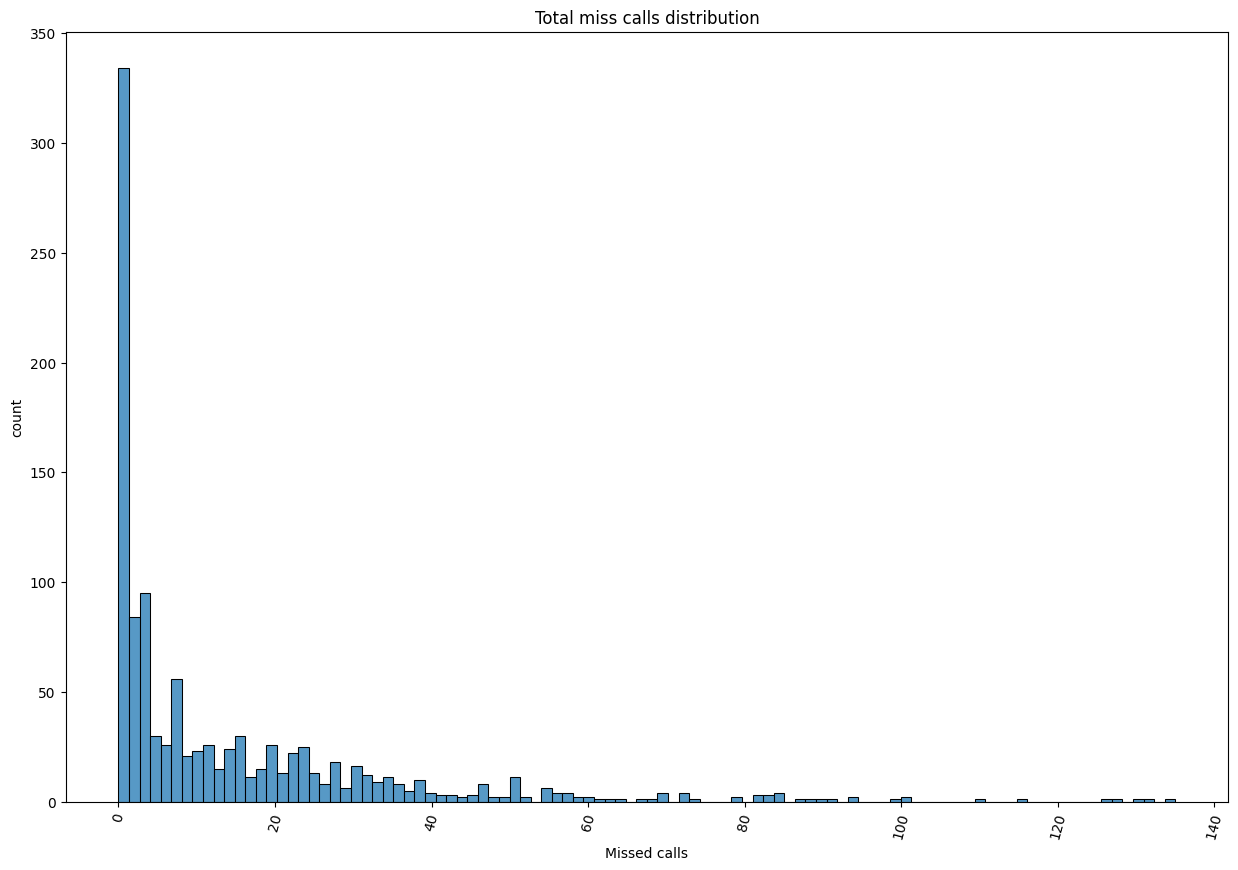

In [32]:
fig, ax = plt.subplots(figsize=(15,10))
sns.histplot(data=stats_by_op, x='total_miss_calls', bins=100)
sns.color_palette("Spectral", as_cmap=True, n_colors=6)
plt.title('Total miss calls distribution')
plt.xlabel('Missed calls')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

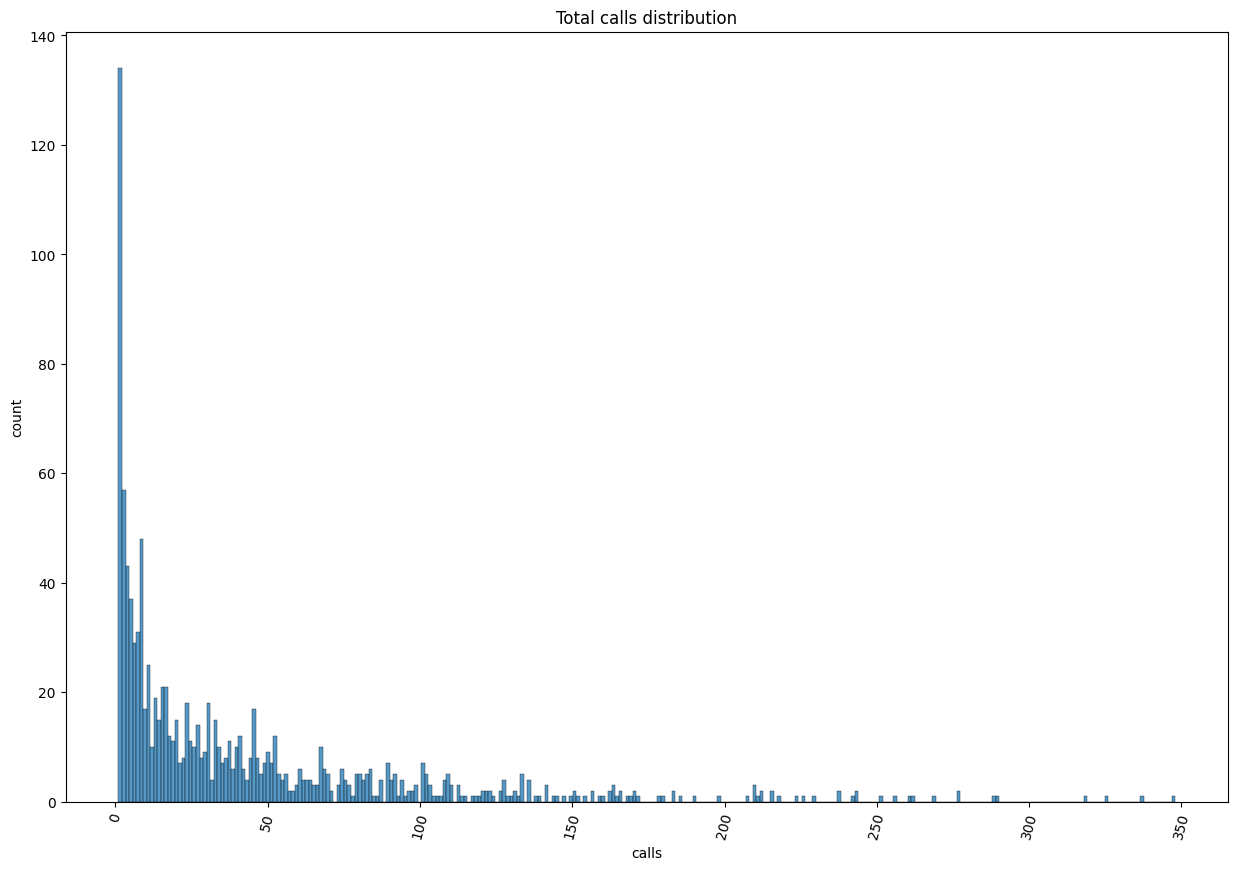

In [33]:
fig, ax = plt.subplots(figsize=(15,10))
sns.histplot(data=stats_by_op, x='total_calls', bins=300)
plt.title('Total calls distribution')
plt.xlabel('calls')
plt.ylabel('count')
plt.xticks(rotation=75)
plt.show()

Con esto, podemos ver que hay una gran proporcion de elementos que si bien tienen 0 llamadas perdida, también los hay con 0 llamadas en el momento y estos individuos deben dar una explicación para esto, así que hemos de dar una primera revisión a estos, para conseguir la lista de aquellos con más tiempos muertos.

In [34]:
in_calls_by_op = telecom[telecom['direction']=='in'].groupby('operator_id').agg({'user_id':'count', 'call_duration':'sum', 'total_call_duration':'sum'}).reset_index()
in_calls_by_op.rename(columns={'user_id':'total_in_calls', 'call_duration':'total_in_call_time', 'total_call_duration':'total_in_op_time'}, inplace=True)
in_calls_by_op['total_in_dead_time'] = in_calls_by_op['total_in_op_time'] - in_calls_by_op['total_in_call_time']
in_calls_by_op

,operator_id,total_in_calls,total_in_call_time,total_in_op_time,total_in_dead_time
0,879896,23,5662,6281,619
1,879898,64,7055,8860,1805
2,880020,8,344,402,58
3,880022,8,512,624,112
4,880026,19,1632,1782,150
...,...,...,...,...,...
749,971102,5,10628,11998,1370
750,971354,2,743,827,84
751,972412,1,120,145,25
752,972460,2,28,36,8


In [35]:
out_calls_by_op = telecom[telecom['direction']=='out'].groupby('operator_id').agg({'user_id':'count', 'call_duration':'sum', 'total_call_duration':'sum'}).reset_index()
out_calls_by_op.rename(columns={'user_id':'total_out_calls', 'call_duration':'total_out_call_time', 'total_call_duration':'total_out_op_time'}, inplace=True)
out_calls_by_op['total_out_dead_time'] = out_calls_by_op['total_out_op_time'] - out_calls_by_op['total_out_call_time']
out_calls_by_op

,operator_id,total_out_calls,total_out_call_time,total_out_op_time,total_out_dead_time
0,879896,105,77599,91146,13547
1,879898,187,271823,382990,111167
2,880020,14,1946,2222,276
3,880022,68,17792,22055,4263
4,880026,179,168042,191884,23842
...,...,...,...,...,...
877,972408,3,200,275,75
878,972410,4,3777,5275,1498
879,972412,4,3378,4403,1025
880,972460,7,2293,3086,793


## 2. Identificar operadores ineficnientes.

### 2.1 Operadores ineficazes dependiendo del número de llamadas perdidas

Par esto tomaremos la tabla creada a partir de nuestras bases de datos crudas. Para eso entonces necesitamos organizar y obtener estos datos.

In [36]:
stats_by_op['Proportion_missed_calls'] = (stats_by_op['total_miss_calls']/stats_by_op['total_calls'])*100
stats_by_op.sort_values(by='Proportion_missed_calls', ascending=False)

,operator_id,total_calls,total_call_time,total_op_time,total_dead_time,total_miss_calls,total_miss_op_time,Proportion_missed_calls
617,932246,1,0,60,60,1,60,100.0
697,937770,1,0,37,37,1,37,100.0
1080,970258,1,0,11,11,1,11,100.0
386,914626,1,0,0,0,1,0,100.0
687,937710,1,0,15,15,1,15,100.0
...,...,...,...,...,...,...,...,...
595,930510,4,645,707,62,0,0,0.0
594,930326,10,1490,1635,145,0,0,0.0
593,930264,3,399,438,39,0,0,0.0
580,929340,6,1416,1765,349,0,0,0.0


In [37]:
stats_by_op.sort_values(by='total_miss_calls', ascending=False)

,operator_id,total_calls,total_call_time,total_op_time,total_dead_time,total_miss_calls,total_miss_op_time,Proportion_missed_calls
28,885876,319,4663954,6200335,1536381,135,834783,42.319749
78,891410,290,369624,407064,37440,131,12106,45.172414
108,893804,325,307082,394536,87454,130,34813,40.000000
203,901880,337,475005,531203,56198,128,22448,37.982196
79,891414,277,304036,329745,25709,126,7003,45.487365
...,...,...,...,...,...,...,...,...
595,930510,4,645,707,62,0,0,0.000000
594,930326,10,1490,1635,145,0,0,0.000000
593,930264,3,399,438,39,0,0,0.000000
580,929340,6,1416,1765,349,0,0,0.000000


Aquí identificamos un rpoblema, hay varios datos que muestra a operadores con muy pocas llamadas, gente que se le género una clave y por temas de rotación de personal o motivos persoanles, ya no continuo con su trabajo en la empresa, por lo cual lo importante ahora es generar filtros para decidir si trabajamos con la totalidad de las llamadas (cantidad) o la proporción de las mismas (cálidad), para esto generamos pércentiles para ambas parte y observamos como se comporta cada uno, deciciendo así como vamos a identificar a un operador ineficaz.

In [38]:
min_calls = 15 
stats_filtered = stats_by_op[stats_by_op['total_calls'] >= min_calls].copy()

p70 = stats_filtered['total_miss_calls'].quantile(0.70)
p80 = stats_filtered['total_miss_calls'].quantile(0.80)
p90 = stats_filtered['total_miss_calls'].quantile(0.90)

print(f"Percentil 70: {p70}")
print(f"Percentil 80: {p80}")
print(f"Percentil 90: {p90}")

Percentil 70: 27.0
Percentil 80: 35.0
Percentil 90: 51.0


In [39]:
p70 = stats_filtered['Proportion_missed_calls'].quantile(0.70)
p80 = stats_filtered['Proportion_missed_calls'].quantile(0.80)
p90 = stats_filtered['Proportion_missed_calls'].quantile(0.90)

print(f"Percentil 70: {p70}")
print(f"Percentil 80: {p80}")
print(f"Percentil 90: {p90}")


Percentil 70: 42.92207792207792
Percentil 80: 47.040998217468804
Percentil 90: 51.303135888501735


Con base a esto, vamos a tomar una decisón, de considerar que todo aquel operador con un porcentaje de llamadas perdidas superior al 47% es considerado ineficaz para este estudio y esta lista particular. Obteniendo así la lista de personas que serían

In [40]:
Miss_ops = stats_by_op[(stats_by_op['total_calls'] >= min_calls) & (stats_by_op['Proportion_missed_calls']>=p80)]
Miss_ops

,operator_id,total_calls,total_call_time,total_op_time,total_dead_time,total_miss_calls,total_miss_op_time,Proportion_missed_calls
4,880026,198,169674,193666,23992,94,13028,47.474747
24,884478,93,51066,88310,37244,44,22587,47.311828
30,886146,19,5916,7070,1154,10,698,52.631579
59,890410,164,214515,238964,24449,84,12794,51.219512
62,890420,89,124092,137880,13788,47,6952,52.808989
...,...,...,...,...,...,...,...,...
977,954642,17,18618,27176,8558,8,3625,47.058824
1029,960672,24,20217,24136,3919,12,1727,50.000000
1047,964716,20,27562,29851,2289,11,900,55.000000
1051,965540,21,80187,102319,22132,10,10602,47.619048


Considerando esto ahora nos faltan 2 enfoques más, considerando lo que se nos solicitó por parte del cliente; en este generamos una lista de los operadores ineficaces con sus métricas asociadas. Ahora debemos realizar lo mismo pero considerando, los otros enfoques solicitados

### 2.2 Operadores ineficazes dependiendo del tiempo muerto para llamadas

Aquí, a diferencia del enfoque anterior, estamos trabajando con un enfoque absoluto, pues el tiempo muerto es tiempo muerto independiente de todo contexto, por lo que la métodogía continua.

In [41]:
in_calls_by_op.sort_values(by='total_in_dead_time', ascending=False)

,operator_id,total_in_calls,total_in_call_time,total_in_op_time,total_in_dead_time
335,919790,71,119862,179488,59626
288,913938,84,389685,434629,44944
334,919554,84,129548,173073,43525
333,919552,76,156534,198849,42315
337,919794,37,102382,140845,38463
...,...,...,...,...,...
617,946020,1,5,8,3
675,952954,3,23,26,3
663,952114,1,6,9,3
64,891948,1,33,36,3


In [42]:
min_calls = 15 
stats_filtered = in_calls_by_op[in_calls_by_op['total_in_calls'] >= min_calls].copy()

p70 = stats_filtered['total_in_dead_time'].quantile(0.70)
p80 = stats_filtered['total_in_dead_time'].quantile(0.80)
p90 = stats_filtered['total_in_dead_time'].quantile(0.90)

print(f"Percentil 70: {p70:.2f}")
print(f"Percentil 80: {p80:.2f}")
print(f"Percentil 90: {p90:.2f}")

Percentil 70: 3497.10
Percentil 80: 5646.20
Percentil 90: 9721.30


Es entonces que consideramos aquí un enfoque robusto donde todo aquel que tenga más de 5646.2 minutos y más de 15 llamadas entrantes en el historial, es entonces un usuario ineficaz. 

In [43]:
deadtime_ops = in_calls_by_op[(in_calls_by_op['total_in_calls'] >= min_calls) & (in_calls_by_op['total_in_dead_time']>=p80)]
deadtime_ops


,operator_id,total_in_calls,total_in_call_time,total_in_op_time,total_in_dead_time
9,882684,52,137935,147905,9970
10,882686,71,155665,167731,12066
12,882690,24,14979,22175,7196
21,885876,103,69180,79680,10500
22,885890,103,87423,99818,12395
...,...,...,...,...,...
598,944226,54,28865,37715,8850
638,948286,42,20276,26392,6116
659,951508,35,30654,37091,6437
674,952948,37,459200,465825,6625


Obteniendo así a 61 elementos ineficaces en este ambito. Faltaría un elemento más el cual es:


### 2.3 Operadores ineficazes dependiendo del número de llamadas salientes

In [44]:
out_calls_by_op = out_calls_by_op.merge(stats_by_op[['operator_id', 'total_calls']], on='operator_id', how='left')
out_calls_by_op['percent_out_calls'] = out_calls_by_op['total_out_calls']/out_calls_by_op['total_calls']*100
out_calls_by_op

,operator_id,total_out_calls,total_out_call_time,total_out_op_time,total_out_dead_time,total_calls,percent_out_calls
0,879896,105,77599,91146,13547,128,82.031250
1,879898,187,271823,382990,111167,251,74.501992
2,880020,14,1946,2222,276,22,63.636364
3,880022,68,17792,22055,4263,76,89.473684
4,880026,179,168042,191884,23842,198,90.404040
...,...,...,...,...,...,...,...
877,972408,3,200,275,75,3,100.000000
878,972410,4,3777,5275,1498,4,100.000000
879,972412,4,3378,4403,1025,5,80.000000
880,972460,7,2293,3086,793,9,77.777778


In [46]:
min_calls = 15 
stats_filtered = out_calls_by_op[out_calls_by_op['total_calls'] >= min_calls].copy()

p70 = stats_filtered['total_out_calls'].quantile(0.70)
p80 = stats_filtered['total_out_calls'].quantile(0.80)
p90 = stats_filtered['total_out_calls'].quantile(0.90)

print(f"Percentil 70: {p70:.2f}")
print(f"Percentil 80: {p80:.2f}")
print(f"Percentil 90: {p90:.2f}")

Percentil 70: 61.00
Percentil 80: 81.00
Percentil 90: 111.00


In [47]:
min_calls = 15 
stats_filtered = out_calls_by_op[out_calls_by_op['total_calls'] >= min_calls].copy()

p70 = stats_filtered['percent_out_calls'].quantile(0.70)
p80 = stats_filtered['percent_out_calls'].quantile(0.80)
p90 = stats_filtered['percent_out_calls'].quantile(0.90)

print(f"Percentil 70: {p70:.2f}")
print(f"Percentil 80: {p80:.2f}")
print(f"Percentil 90: {p90:.2f}")

Percentil 70: 97.83
Percentil 80: 100.00
Percentil 90: 100.00


In [48]:
min_calls = 15 
stats_filtered = out_calls_by_op[out_calls_by_op['total_calls'] >= min_calls].copy()

p30 = stats_filtered['percent_out_calls'].quantile(0.30)
p40 = stats_filtered['percent_out_calls'].quantile(0.40)
p50 = stats_filtered['percent_out_calls'].quantile(0.50)

print(f"Percentil 30: {p30:.2f}")
print(f"Percentil 40: {p40:.2f}")
print(f"Percentil 50: {p50:.2f}")

Percentil 30: 64.58
Percentil 40: 69.23
Percentil 50: 76.53


In [49]:
low_out_ops = out_calls_by_op[(out_calls_by_op['total_calls'] >= min_calls) & (out_calls_by_op['percent_out_calls']<=p30)]
low_out_ops

,operator_id,total_out_calls,total_out_call_time,total_out_op_time,total_out_dead_time,total_calls,percent_out_calls
2,880020,14,1946,2222,276,22,63.636364
19,884408,11,448,1060,612,27,40.740741
25,885890,174,3579710,5153731,1574021,277,62.815884
39,888868,19,2459,3583,1124,34,55.882353
54,890582,29,1075,1852,777,73,39.726027
...,...,...,...,...,...,...,...
790,955032,16,588,1277,689,28,57.142857
824,959312,20,6702,8159,1457,34,58.823529
828,960620,20,3164,4293,1129,33,60.606061
837,962268,20,4718,6735,2017,33,60.606061


Considerando esto, entonces lo propio ahora sería verificar que tan problematicos o ineficientes son nuestros elementos de capital humano. Para ello, debemos realizar una serie de hipotesis para cada uno de los diferentes indicadores. 

## 3. Pruebas de hipótesis


Para esto debemos primero considerar las diversas metricas que medimos, tomar como referencia el mercado y generar las pruebas para ver si nuestro departamento se acerca a lo esperado y considerado eficiente en el área.

### 3.1 Prueba de hipotesis para la eficiencia en el indice de llamadas perdidas

Dentro de las investigación realizada encontramos que, existe un parametro de referencia el cual dice "Para las llamadas perdidas la tasa promedio de abandono de llamadas alcanzó el 5.91%" por lo que hemos de realizar una prueba en la cual planteamos una hipótesis nula y una alternativa tal que:
 * **H0** el porcentaje de llamadas perdidas es menor o igual al 5.91% del mercado
 * **H1** el porcentaje de llamadas perdidas es mayor al 5.91% del mercado

In [50]:
benchmark_missed = 5.91
alpha = 0.05

ineffective_missed_calls = Miss_ops['Proportion_missed_calls']

results = stats.ttest_1samp(ineffective_missed_calls, benchmark_missed)

print('valor p: ', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  3.9898606268571705e-136
Rechazamos la hipótesis nula


Esto nos muestra que hay un problema grave de eficiencia en estos elementos más allá de lo que es considerado acepable, por lo tanto es necesario generar una nueva estrategía de trabajo para realizar con estos 126 elementos e identificar cuales cumplen con 3 de estas faltas. Para reportarlo con el departamento de rh y ellos tomen su decisión.

### 3.2 Prueba de hipotesis para la eficiencia en el indice tiempo muerto en llamadas entrantes


Para esto también revisamo identificadores de mercado por lo cual pudimos obtener que en "el El 80% de las llamadas se contestan en los 20 segundos de iniciada". por lo cual el tiempo forma otra pureba de las siguientes hipotesis.
 * **H0** el tiempo muerto en llamadas entrantes es mayor o igual a los 20 segundos del mercado
 * **H1** el tiempo muerto en llamadas entrantes es menor a los 20 segundos del mercado


In [51]:
benchmark_time = 20
alpha = 0.05

deadtimes_calls = deadtime_ops['total_in_dead_time']

results = stats.ttest_1samp(deadtimes_calls, benchmark_time)

print('valor p: ', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  2.2633081949792273e-13
Rechazamos la hipótesis nula


Entonces vemos de esta forma que, efectivamente en este indice tampoco se encuentra un buen desempeño, por lo que es necesario cotejar las listas de usarios otra vez y generar listas de quienes no cumplen con 1, 2 y 3 de estas marcas importantes.

### 3.3 Prueba de hipotesis para la eficiencia en el indice de llamadas salientes

Para esto también revisamo identificadores de mercado por lo cual pudimos obtener que en "un porcentaje alto de llamadas salientes es superior al 50%". por lo cual el tiempo forma otra pureba de las siguientes hipotesis.
 * **H0** el porcentaje de llamadas es mayor o igual al 50% del mercado
 * **H1** el porcentaje de llamadas es menor al 50% del mercado


In [52]:
benchmark_percent = 50
alpha = 0.05

out_per_calls = low_out_ops['percent_out_calls']

results = stats.ttest_1samp(out_per_calls, benchmark_percent)

print('valor p: ', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  0.03183434695689193
Rechazamos la hipótesis nula


Es de esta forma que rechazamos la hipotesis y encontamos que efectivamente, la oficina tiene bastantes problemas con una lista de individuos los cuales citaremos a cuntinuación, donde todo esto no permite el correcto funcionamiento de las empresas.

In [53]:
set_missed = set(Miss_ops['operator_id'])
set_deadtime = set(deadtime_ops['operator_id']) 
set_low_out = set(low_out_ops['operator_id'])

In [54]:
print("elementos que no cumplen con los parametros de eficiencia para llamadas perdidas")
print(*set_missed)

elementos que no cumplen con los parametros de eficiencia para llamadas perdidas
923666 948756 922142 890410 890420 890422 952392 920146 900180 902742 922710 902744 902746 902748 930914 915558 964716 905842 906866 952948 902774 953462 902776 919162 902778 892028 902782 945278 945280 945282 914052 945284 945286 941192 945288 945290 952458 952460 945294 967310 945296 929426 932498 929428 945298 945302 952468 906392 919192 919194 945304 919196 945308 915614 919198 919200 960672 919202 945314 939684 945316 945318 945320 945322 945324 909502 910530 937156 899788 899790 921316 945894 893674 945900 945902 945904 917234 884478 919302 919306 919310 919314 954642 919318 930586 891162 891170 952114 919362 919364 919370 919372 919376 919378 919382 899932 919390 920414 919906 919910 922476 891252 899964 899968 886146 899972 947592 947604 880026 937372 919456 947620 965540 933806 938414 919476 947640 919482 940474 947658 919504 921574 921584 921592 921594 921596


In [55]:
print("elementos que no cumplen con los parametros de eficiencia para llamadas entrantes")
print(*set_deadtime)

elementos que no cumplen con los parametros de eficiencia para llamadas entrantes
919552 882690 885890 919554 931458 923526 899082 938896 891410 913938 891414 913942 908958 908960 890402 911138 890404 906404 906406 919204 906408 919206 906410 919166 882684 940588 925104 906680 939706 948286 918978 918986 909134 911310 951508 913788 906070 940630 944216 893402 921306 917852 921818 944218 944220 944222 944226 921318 939370 887276 893804 919790 958460 919792 919794 939762 885876 952948 901880 901884 882686


In [56]:
print("elementos que no cumplen con los parametros de eficiencia para llamadas entrantes")
print(*set_low_out)

elementos que no cumplen con los parametros de eficiencia para llamadas entrantes
919552 919554 891908 937988 914440 896014 921102 896018 913938 913942 888868 891946 940588 901178 964666 940614 940616 940622 940624 944210 891988 940630 944216 920666 940634 929884 930908 944218 944220 944222 900194 933986 944226 944228 940652 960620 892530 940658 892532 938612 892534 938614 892536 953464 919164 903292 919166 928382 935548 944764 885890 920706 931458 944766 900742 905862 900746 916618 905870 903312 920720 929424 920726 920728 926872 955032 920732 906398 908958 908960 919204 919206 906408 906410 899250 900788 884408 939706 939212 907982 933070 951508 890582 921306 962268 925922 921318 919790 919792 919794 893172 901880 890618 900352 924928 937732 937736 937742 894224 920852 937750 937752 900892 924956 937760 908078 937774 908082 937780 937782 920902 909134 914256 959312 937810 937812 906070 917850 929626 944476 904038 939370 893804 904044 901492 898422 913788 896382 954750 924544 924546 9

In [57]:
fail_2_indicators = (
    (set_missed & set_deadtime) - set_low_out |
    (set_missed & set_low_out) - set_deadtime |  
    (set_deadtime & set_low_out) - set_missed    
)

fail_3_indicators = set_missed & set_deadtime & set_low_out

In [58]:
fail_2_indicators

{885890,
 893402,
 893804,
 901880,
 906070,
 906408,
 906410,
 906680,
 908958,
 908960,
 909134,
 911310,
 913788,
 913938,
 913942,
 919166,
 919204,
 919206,
 919552,
 919554,
 919790,
 919792,
 919794,
 921306,
 921318,
 931458,
 938896,
 939370,
 939706,
 940588,
 940630,
 944216,
 944218,
 944220,
 944222,
 944226,
 951508,
 952948}

In [59]:
fail_3_indicators

set()

Econtrando así a los elementos que fallan en estas implementaciones y pudiendo generar una estrategía o plan respecto a ellos.

## 4. Conclusiones

Drive con las conclusiones https://drive.google.com/file/d/1J2KodunIEJmA6gHTl3QUFjaoPwb5GxJu/view?usp=drive_link